Why is Python Slow for Numerical Computing?

Python is slow for large-scale numerical tasks because it is a high-level, dynamic, and interpreted language. For every operation in a loop, Python has to check the type of the objects, handle memory management, and perform bytecode interpretation. This overhead adds up significantly compared to compiled languages.


In [2]:
a =[1 , 2 ,3]
b = [ 4 , 5 ,6 ]

vector_sum= [1+4 ,2 +5 , 3+ 6]

vector_sum

[5, 7, 9]

In [3]:
import time 

size = 10**8

a = list(range(size))
b= list(range(size))
c=[]

start =time.time()
for i in range(size):
    c.append(a[i]+ b[i])
end = time.time()

print(f"Plain Python loop took : {end - start:.4f} seconds")


KeyboardInterrupt: 

In [ ]:
import gc
a , b = None , None
gc.collect()

4042

KeyboardInterrupt: 

In [ ]:

%%writefile speed_test.cpp
#include <iostream>
#include <vector>
#include <chrono>

int main() {
    int size = 100000000;
    std::vector<int> a(size), b(size), c(size);

    auto start = std::chrono::high_resolution_clock::now();
    for(int i = 0; i < size; ++i) {
        c[i] = a[i] + b[i];
    }
    auto end = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> diff = end - start;
    std::cout << "C++ loop took: " << diff.count() << " seconds" << std::endl;
    return 0;
}









Overwriting speed_test.cpp


In [ ]:
!g++ -O3 speed_test.cpp -o speed_test && ./speed_test
# if we run this it will take only 0.113026 seconds , where python took 31.899 seconds

'g++' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
import numpy as np
a_np = np.arange(size)
b_np = np.arange(size)
 
start = time.time()
c_np = a_np + b_np 
end = time.time()
print(f"Numpy vectorization took only ; {end- start : .4f} seconds")

Numpy vectorization took only ;  0.2541 seconds


In [ ]:
# Re using the existing a_np array to store results directly 
# this will give exactly the same level time of c++ using just a library
start = time.time()
np.add(a_np, b_np , out=a_np)
end =time.time()

print(f"In-place Numpy operation took :{ end - start : .4f} seconds")

In-place Numpy operation took : 0.1017 seconds


In [ ]:
import gc
a , b = None , None
gc.collect()

534

Working with numerical data
The "data" in Data Analysis typically refers to numerical data, e.g., stock prices, sales figures, sensor measurements, sports scores, database tables, etc. The Numpy library provides specialized data structures, functions, and other tools for numerical computing in Python. Let's work through an example to see why & how to use Numpy for working with numerical data.

Suppose we want to use climate data like the temperature, rainfall, and humidity to determine if a region is well suited for growing Rice. A simple approach for doing this would be to formulate the relationship between the annual yield of rice (tons per hectare) and the climatic conditions like the average temperature (in degrees Celsius), rainfall (in millimeters) & average relative humidity (in percentage) as a linear equation.

yield_of_rice = w1 * temperature + w2 * rainfall + w3 * humidity

We're expressing the yield of rice/paddy as a weighted sum of the temperature, rainfall, and humidity. This equation is an approximation since the actual relationship may not necessarily be linear, and there may be other factors involved. But a simple linear model like this often works well in practice.

Based on some statical analysis of historical data, we might come up with reasonable values for the weights w1, w2, and w3. Here's an example set of values:

In [ ]:
w1, w2, w3 = 0.3, 0.2, 0.5

Given some climate data for a region , we can now predict the yield of rice .heres some sample data :
![alt text](../Images/4TubQ5m.jpg)

TO begin , we can define some variables to record climate data for a region 

In [ ]:
rajshahi_temp = 26
rajshahi_rainfall = 1507
rajshahi_humidity = 72

In [ ]:
rajshahi_yield_rice = rajshahi_temp * w1 + rajshahi_rainfall * w2 + rajshahi_humidity * w3
rajshahi_yield_rice

print(f"The expected yield of rice on Rajshahi region is {rajshahi_yield_rice} tons per hectare")

The expected yield of rice on Rajshahi region is 345.20000000000005 tons per hectare


To make it slightly easier to perform the above computation for multiple regions, we can represent the climate data for each region as a vector, i.e., a list of numbers.

In [ ]:
# Region = [Temp, Rainfall, Humidity]

rajshahi    =   [26, 1507, 72]
rangpur     =   [25, 2059, 75]
dhaka       =   [27, 1872, 73]
khulna      =   [27, 1701, 74]
barishal    =   [26, 1971, 80]
chattogram  =   [26, 2938, 78]
sylhet      =   [26, 3909, 77]

In [ ]:
weights =[w1, w2 , w3]

We can now write a function crop_yield to calcuate the yield of rice (or any other crop) given the climate data and the respective weights.


In [ ]:
def crop_yield(region,weights):
    result = 0
    for x, w in zip(region,weights):# this is taking each pair of ( x, w ) and 
        #multuiplying them then storing the multiplication in the result 
        result += x * w
    return result

How the loops knows the number of iteration ??

Zip can take more than2 variables too!!

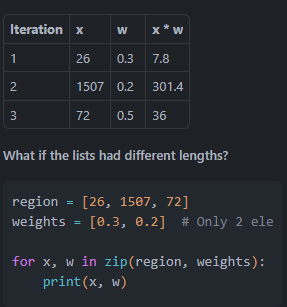
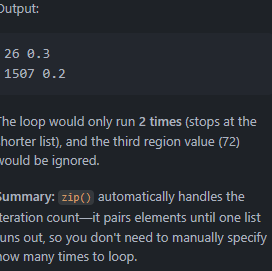

In [ ]:
crop_yield(rajshahi ,weights)

345.20000000000005

In [ ]:
crop_yield(rangpur,weights)

456.8

Going from Python lists to Numpy arrays
The calculation performed by the crop_yield (element-wise multiplication of two vectors and taking a sum of the results) is also called the dot product. Learn more about dot product here: https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces/dot-cross-products/v/vector-dot-product-and-vector-length .

The Numpy library provides a built-in function to compute the dot product of two vectors. However, we must first convert the lists into Numpy arrays.

Let's install the Numpy library using the pip package manager.

In [ ]:
import numpy as np

In [ ]:
rangpur = np.array([25,2059,75])

In [ ]:
rangpur

array([  25, 2059,   75])

In [ ]:
weights = np.array([w1,w2,w3])

In [ ]:
weights

array([0.3, 0.2, 0.5])

In [ ]:
type(rangpur)

numpy.ndarray

In [ ]:
type(weights)

numpy.ndarray

In [ ]:
weights[0]

np.float64(0.3)

In [ ]:
rangpur[2].dtype

dtype('int64')

In [ ]:
np.dot(rangpur,weights)

np.float64(456.8)

In [ ]:
(rangpur * weights ).sum()

np.float64(456.8)

In [ ]:
arr1 = np.array([1,2,3])
arr2=np.array([4,5,6])

In [ ]:
arr1  * arr2 

array([ 4, 10, 18])

Benefits of using Numpy arrays
Numpy arrays offer the following benefits over Python lists for operating on numerical data:

Ease of use: You can write small, concise, and intuitive mathematical expressions like (kanto * weights).sum() rather than using loops & custom functions like crop_yield.
Performance: Numpy operations and functions are implemented internally in C++, which makes them much faster than using Python statements & loops that are interpreted at runtime

Multi-dimensional Numpy arrays


![alt text](mg8O3kd.png)


We can now go one step further and represent the climate data for all the regions using a single 2-dimensional Numpy array.

In [3]:
import numpy as np
climate_data = np.array(
                       [[26, 1507, 72],   # rajshahi
                        [25, 2059, 75],   # rangpur
                        [27, 1872, 73],   # dhaka
                        [27, 1701, 74],   # khulna
                        [26, 1971, 80],   # barishal
                        [26, 2938, 78],   # chattogram
                        [26, 3909, 77]]   # sylhet
                            )

In [ ]:
climate_data

(7, 3)

In [ ]:
climate_data.shape

(7, 3)

In [ ]:
weights.shape

(3,)

All the elements in a numpy array have the same data type. You can check the data type of an array using the .dtype property .We cant mix up data tyeps in numPy array


 an array contains even a single floating point number, all the other elements are also converted to floats.

We can now compute the predicted yields of rice in all the regions, using a single matrix multiplication between climate_data (a 7x3 matrix) and weights (a vector of length 3). Here's what it looks like visually:

![alt text](LJ2WKSI.png)

You can learn about matrices and matrix multiplication by watching the first 3-4 videos of this playlist: https://www.youtube.com/watch?v=xyAuNHPsq-g&list=PLFD0EB975BA0CC1E0&index=1 .

We can use the np.matmul function or the @ operator to perform matrix multiplication.

In [ ]:
np.matmul(climate_data , weights)

array([345.2, 456.8, 419. , 385.3, 442. , 634.4, 828.1])

In [ ]:
climate_data @ weights  # we can also use this syntax for multiplication

array([345.2, 456.8, 419. , 385.3, 442. , 634.4, 828.1])

Arithmetic operations, broadcasting and comparison
Numpy arrays support arithmetic operators like +, -, *, etc. You can perform an arithmetic operation with a single number (also called scalar) or with another array of the same shape. Operators make it easy to write mathematical expressions with multi-dimensional arrays.

In [ ]:
arr = np.array([1, 2, 3])

In [ ]:
arr +1

array([2, 3, 4])

In [ ]:
arr1 = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

arr2 = np.array([
    [7, 8, 9],
    [10, 11, 12]
])

In [ ]:
arr1 * arr2

array([[ 7, 16, 27],
       [40, 55, 72]])

In [ ]:
arr1 + arr2

array([[ 8, 10, 12],
       [14, 16, 18]])

Broadcasting different numbers of dimensions but compatible shapes

In [ ]:
arr1 = np.array([[1, 2, 3, 4],
                 [5, 6, 7, 8],
                 [9, 1, 2, 3]])

arr2 = np.array([10, 20, 30, 40])

In [ ]:
arr1 + arr2

array([[11, 22, 33, 44],
       [15, 26, 37, 48],
       [19, 21, 32, 43]])

In [ ]:
arr1 * arr2 # the 2nd array will be multiplied to all of the rows of the first array

array([[ 10,  40,  90, 160],
       [ 50, 120, 210, 320],
       [ 90,  20,  60, 120]])

In [ ]:
arr1 = np.array([[1, 2, 3, 4],
                 [5, 6, 7, 8],
                 [9, 1, 2, 3]])

arr2 = np.array([10, 20, 30]) # this cant be added because the shape isnt compitible 

In [ ]:
arr1 + arr2

ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

data type , reshape most important  

Array Comparison

In [6]:
arr1 = np.array([[1, 2, 3], [4, 5, 6]])
arr2 = np.array([[2, 2, 3], [1, 2, 6]])

In [7]:
arr1==arr2

array([[False,  True,  True],
       [False, False,  True]])

In [8]:
arr1!= arr2

array([[ True, False, False],
       [ True,  True, False]])

In [9]:
arr1 >=arr2

array([[False,  True,  True],
       [ True,  True,  True]])

In [ ]:
(arr1==arr2).sum() # it will summ all the true values as they represent 1

np.int64(3)

In [ ]:
(arr1==arr2).std() # calculates standard deviation 

np.float64(0.5)

Array indexing and slicing


Numpy extends Python's list indexing notation using [] to multiple dimensions in an intuitive fashion. You can provide a comma-separated list of indices or ranges to select a specific element or a subarray (also called a slice) from a Numpy array.

In [ ]:
arr3= np.array([
                [[11,12,13,14], #0th index
                 [13,14,15,16]],
                
                [[15,16,17,21], #1st index
                [63,92,36,18]],
                
                [[98,32,81,23], #2nd index
                [17,18,19.5,43]]
               
               ]) # this is a 3D array 

In [15]:
arr3.shape


(3, 2, 4)

In [16]:
arr3[1,1,2]

np.float64(36.0)

In [ ]:
# subarray using ranges 
arr3[1: , 0:1 , :2] # From 1st index of 1st dim ( means 1st , and 2nd both matrix) ,then from 0 to excluded 1 (means only 0th rows of 2nd dim)
                    # Finally in the 3rd dim select until 2nd index ( 2nd index excluded)

array([[[15., 16.]],

       [[98., 32.]]])

In [22]:
arr3[1 , 1 ,0:4]

array([63., 92., 36., 18.])

In [23]:
arr3[1: , 1 ,3]

array([18., 43.])

In [24]:
arr3[1]

array([[15., 16., 17., 21.],
       [63., 92., 36., 18.]])

In [25]:
arr3[:2,1]

array([[13., 14., 15., 16.],
       [63., 92., 36., 18.]])

Other ways of creating Numpy arrays
Numpy also provides some handy functions to create arrays of desired shapes with fixed or random values. Check out the official documentation or use the help function to learn more. 

In [26]:
np.zeros((3,2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [31]:
np.ones([4,2,2])

array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]])

In [34]:
np.eye(6)

array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [35]:
np.random.rand(5)

array([0.21829215, 0.46542673, 0.7952229 , 0.5817694 , 0.53839369])

In [36]:
np.random.rand(2,3,4)

array([[[0.20583041, 0.74239487, 0.12581765, 0.98245884],
        [0.92266188, 0.72011689, 0.35724006, 0.76243043],
        [0.72998532, 0.93195057, 0.17207872, 0.37893643]],

       [[0.14301474, 0.43497216, 0.44165755, 0.28047146],
        [0.44785179, 0.16501997, 0.61436146, 0.74452742],
        [0.44557429, 0.13750209, 0.95180338, 0.96522374]]])

In [37]:
# Random matrix
np.random.randn(2, 3) # rand vs. randn - what's the difference?

array([[-0.98760782, -0.082614  ,  0.6607148 ],
       [-0.03546426, -0.26819558, -0.60790549]])

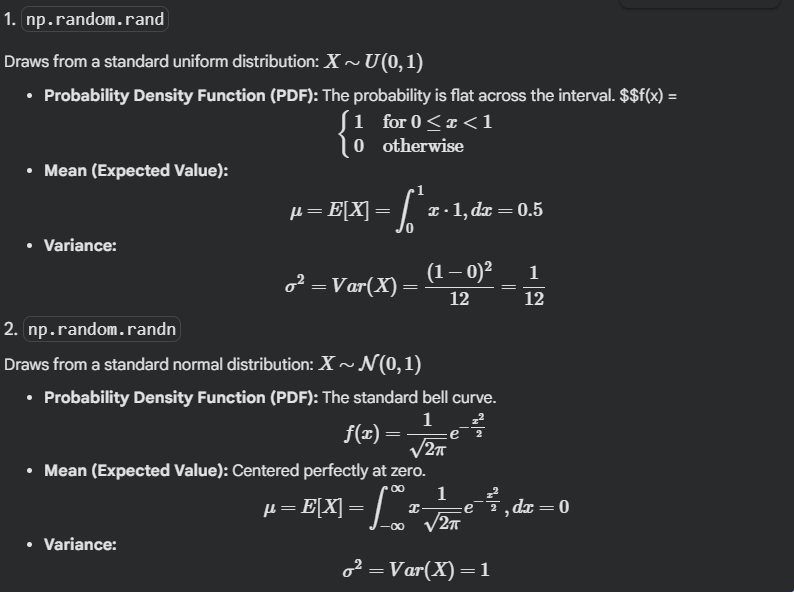

In [38]:
np.full([2,3,4],32)

array([[[32, 32, 32, 32],
        [32, 32, 32, 32],
        [32, 32, 32, 32]],

       [[32, 32, 32, 32],
        [32, 32, 32, 32],
        [32, 32, 32, 32]]])

In [ ]:
np.arange(10,90,3) #Range with start , end and gap


array([10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58,
       61, 64, 67, 70, 73, 76, 79, 82, 85, 88])

In [2]:
import numpy as np
np.linspace(3,100,10) # Equally spaced numbers in a range 
# start , end , in how many parts we want to divide 

array([  3.        ,  13.77777778,  24.55555556,  35.33333333,
        46.11111111,  56.88888889,  67.66666667,  78.44444444,
        89.22222222, 100.        ])